### Notebook overview
This notebook reproduces an **unconditional (baseline)** forecast for a single macroeconomic time series using **BISTRO** (BIS Time-series Regression Oracle), as described in the accompanying paper.

- **Task**: forecast US CPI inflation (year-over-year), monthly, with no covariates.
- **Workflow**: choose the forecast horizon (PDT) and history length (CTX), run a rolling-origin backtest, and collect probabilistic forecasts (median and uncertainty bands).
- **Outputs**: a window-by-window forecast table and an overlay plot of forecasts versus the realised series.

### Data
- Source: BIS CPI statistics (US CPI, YoY; monthly).
- More CPI series: see `data/`.


### Step 1 - Setup
- Make the project code in `src/` available to the notebook.
- Import the required libraries and helper functions.


### Google Colab users
- Colab may preinstall **NumPy 2.x**.
- After the downgrade runs, it triggers an automatic restart by terminating the current process.


In [8]:
import os
import subprocess

try:
    import numpy as np
    if np.__version__.startswith('2.'):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        # 2. Install the 1.x stack and compatible dependencies to stop the red errors
        # We include specific versions of pandas/scipy that like NumPy 1.x
        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ])

        print("✅ Install complete. Restarting runtime automatically...")

        # 3. Kill the process to force a reload of the new (older) library
        os.kill(os.getpid(), 9)
    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")
except ImportWarning:
    pass

✅ Success! Using NumPy version: 1.26.4


In [9]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    print("Running in Google Colab. Setting up repository quietly...")
    
    # Added -q to suppress git clone output
    !git clone -q https://github.com/bis-med-it/bistro.git
    
    if not 'uni2ts' in sys.modules:
        print("Installing dependencies (this may take a moment)...")
        # Added -q for pip, and redirected all stdout/stderr to completely hide warnings
        !pip install -q -r /content/bistro/requirements.txt > /dev/null 2>&1
        print("Installation complete!")

### Restart Colab to finish setup

To make sure the newly installed packages load correctly, please restart the runtime:

**Runtime → Restart session**

After it restarts, continue by running the next cells below.

In [10]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
  os.chdir('/content/bistro/script')

repo_root = Path(os.path.join('..')).resolve()
src_root = Path(os.path.join('..', 'src')).resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


In [11]:
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison

from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_yoy_monthly_for_daily_inference,
)


### Step 2 - Data and settings
- Set the forecast horizon (PDT) and how much history the model reads (CTX).


In [12]:
MODEL_REPO = repo_root / 'bistro-finetuned'

FREQ = 'M'  # monthly data frequency

PDT = 12   # how many months to forecast ahead
CTX = 240 # how many months of past data the model reads
PSZ = 32  # patch size used by the model (kept as default for this setup)
BSZ = 32  # batch size for faster forecasting
ROLLING_WINDOWS = 4  # how many starting points to evaluate
WINDOW_DISTANCE = 2  # gap (in months) between those starting points

FORECAST_START_DATE = '2023-01-01'

config = {
    "MODEL_REPO": str(MODEL_REPO),
    "PDT": PDT,
    "CTX": CTX,
    "PSZ": PSZ,
    "BSZ": BSZ,
    "ROLLING_WINDOWS": ROLLING_WINDOWS,
    "WINDOW_DISTANCE": WINDOW_DISTANCE,
    "FORECAST_START_DATE": FORECAST_START_DATE,
}


- Load the CPI series and construct rolling test windows.

In [13]:
series1 = repo_root / 'data' / 'bis_cpi_us_yoy_m.csv'

df = pd.read_csv(series1, index_col=0)
df.index = pd.to_datetime(df.index).to_period(freq=FREQ)

target_col = df.columns[0]

prep = prepare_yoy_monthly_for_daily_inference(
    df,
    target_col=target_col,
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

if prep.windows < 1:
    raise ValueError(
        f'Not enough test data after cutoff {prep.train_end} to create a window: '
        f'test_len={(prep.df_yoy_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}.'
    )

ds = PandasDataset(prep.daily_df, target=target_col)
train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=prep.windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)


### Step 3 - Run BISTRO
- Load the pretrained BISTRO checkpoint.
- Generate probabilistic forecasts for each window.


In [14]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=int(config.get("NUM_SAMPLES", 100)),
    target_dim=1, #int(target_dim),
    feat_dynamic_real_dim=0, #int(feat_dynamic_real_dim),
    past_feat_dynamic_real_dim= 0 #int(past_feat_dynamic_real_dim),
)

Loading weights from local directory


In [15]:
predictor = model.create_predictor(batch_size=BSZ)

inputs    = list(test_data.input)
labels    = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

### Step 4 - Review results
- Summarise forecasts in a table (median by window).
- Plot forecast paths and uncertainty bands against the realised series.


In [16]:
bistro_monthly_by_window = {}
rmse_rows = []

for w in range(prep.windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)
    label_target = np.asarray(labels[w]["target"], dtype=float)

    inp_target = (
        np.asarray(inputs[w]["target"], dtype=float)
        if "target" in inputs[w]
        else np.asarray([], dtype=float)
    )
    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1],
        },
        index=pred_index,
    )
    bistro_monthly_by_window[w] = dfw

    actual = prep.df_monthly[target_col].reindex(pred_index).astype(float)
    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()
    rmse = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    rmse_rows.append(
        {
            "window": w,
            "test_start": pred_index[0],
            "test_end": pred_index[-1],
            "rmse": rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)


In [17]:
rmse_table

,window,test_start,test_end,rmse,n_valid
0,0,2023-01,2023-12,1.656932,12
1,1,2023-03,2024-02,1.934579,12
2,2,2023-05,2024-04,0.878528,12
3,3,2023-07,2024-06,1.191082,12


In [18]:
bistro_monthly_by_window[0]

,bistro_pred,bistro_lo,bistro_hi
2023-01,6.335750,6.119744,6.561955
2023-02,6.021064,5.750042,6.259165
2023-03,5.884797,5.629676,6.147322
2023-04,5.776459,5.577259,6.014336
2023-05,5.612239,5.334595,5.883883
2023-06,5.517082,5.240340,5.801428
2023-07,5.379249,5.048532,5.675980
2023-08,5.216289,4.929547,5.596419
2023-09,5.346907,5.005974,5.582009
2023-10,5.329141,4.951278,5.556274


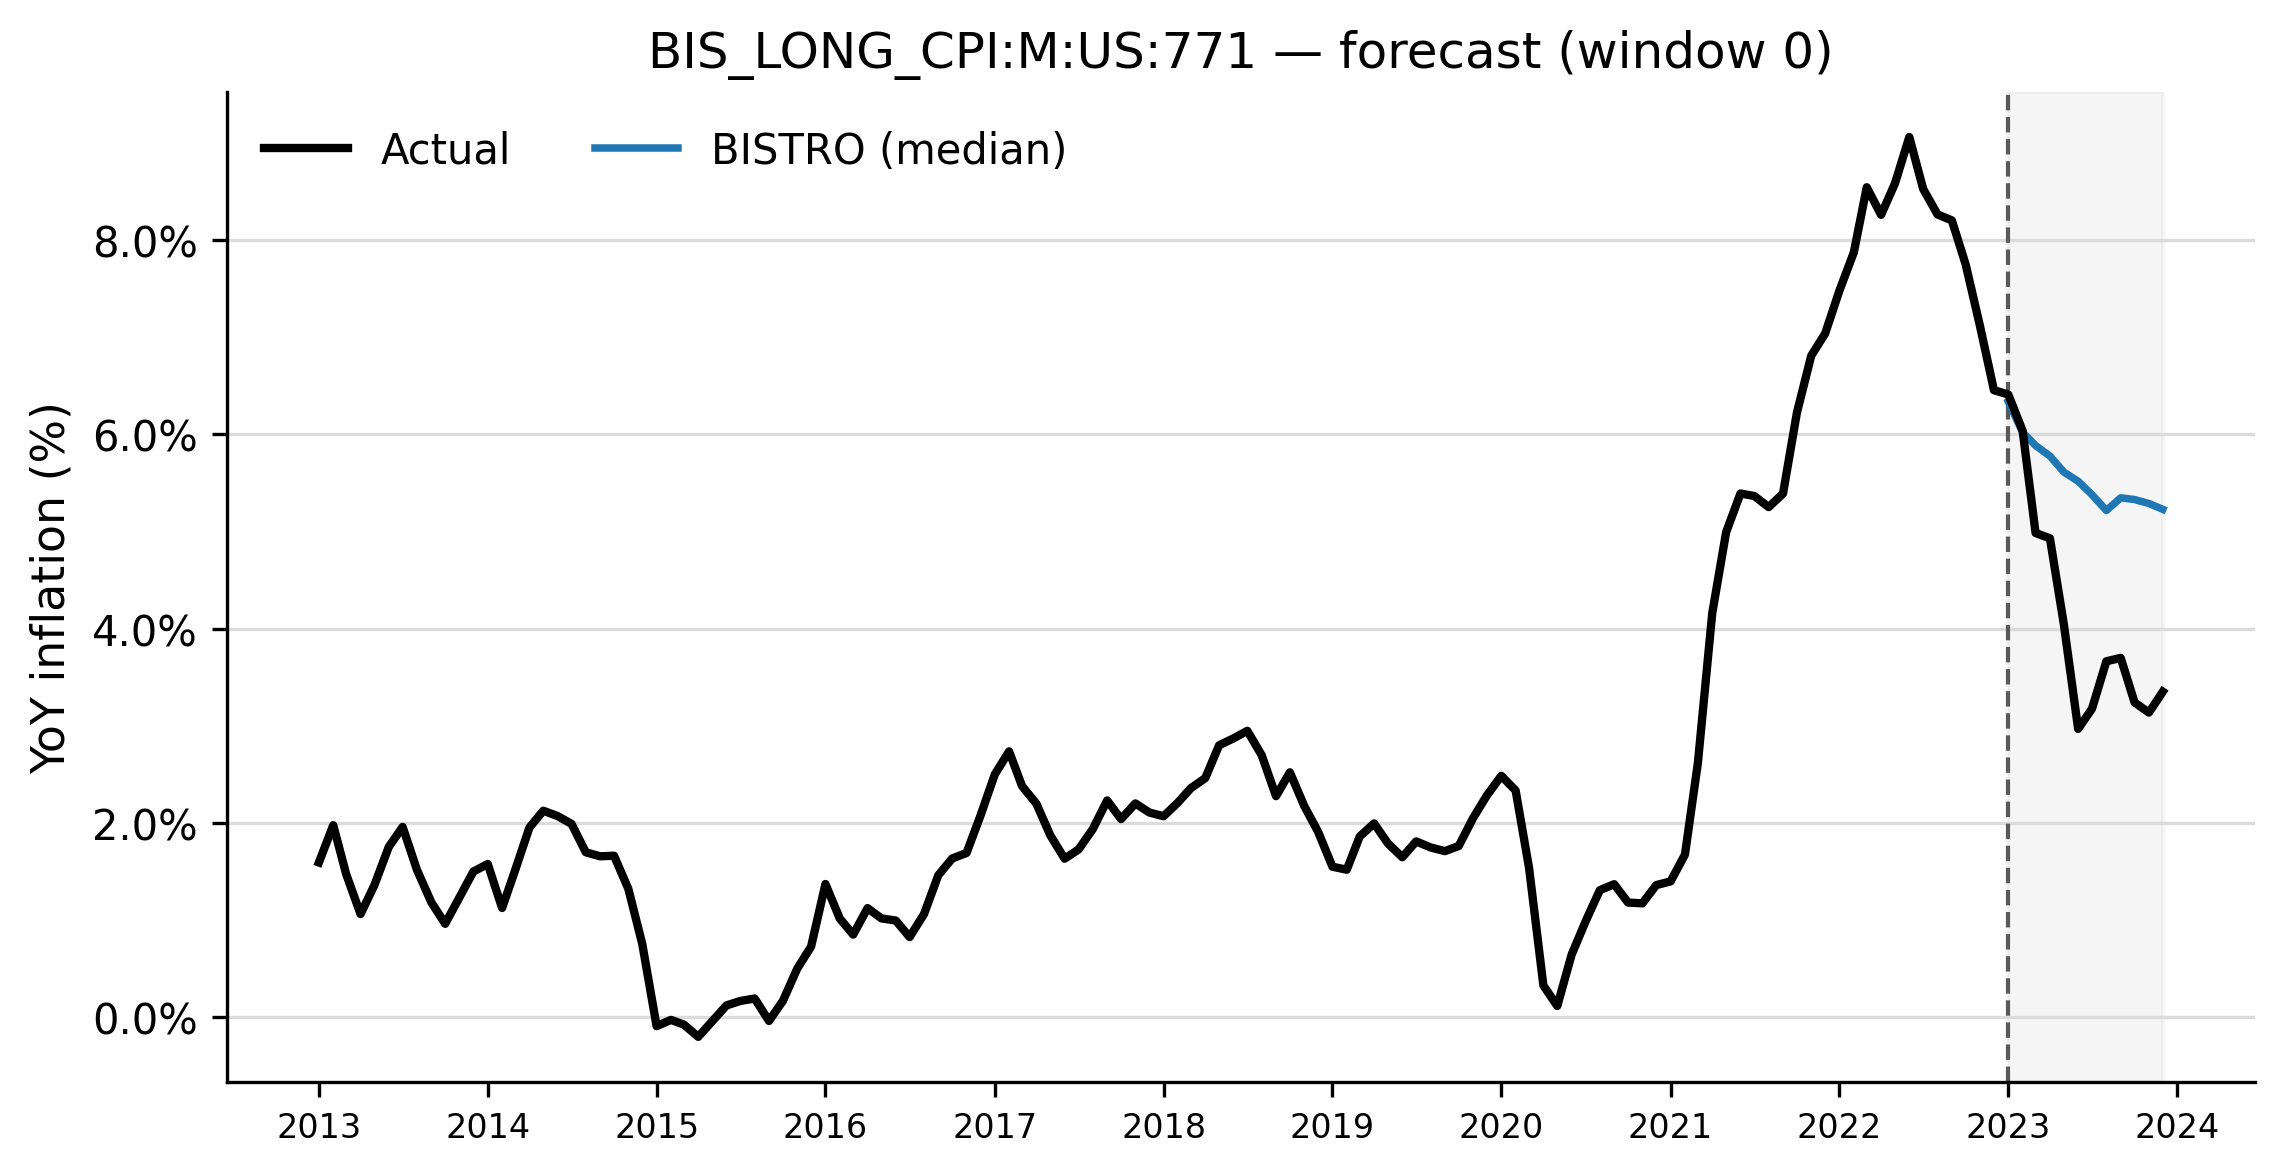

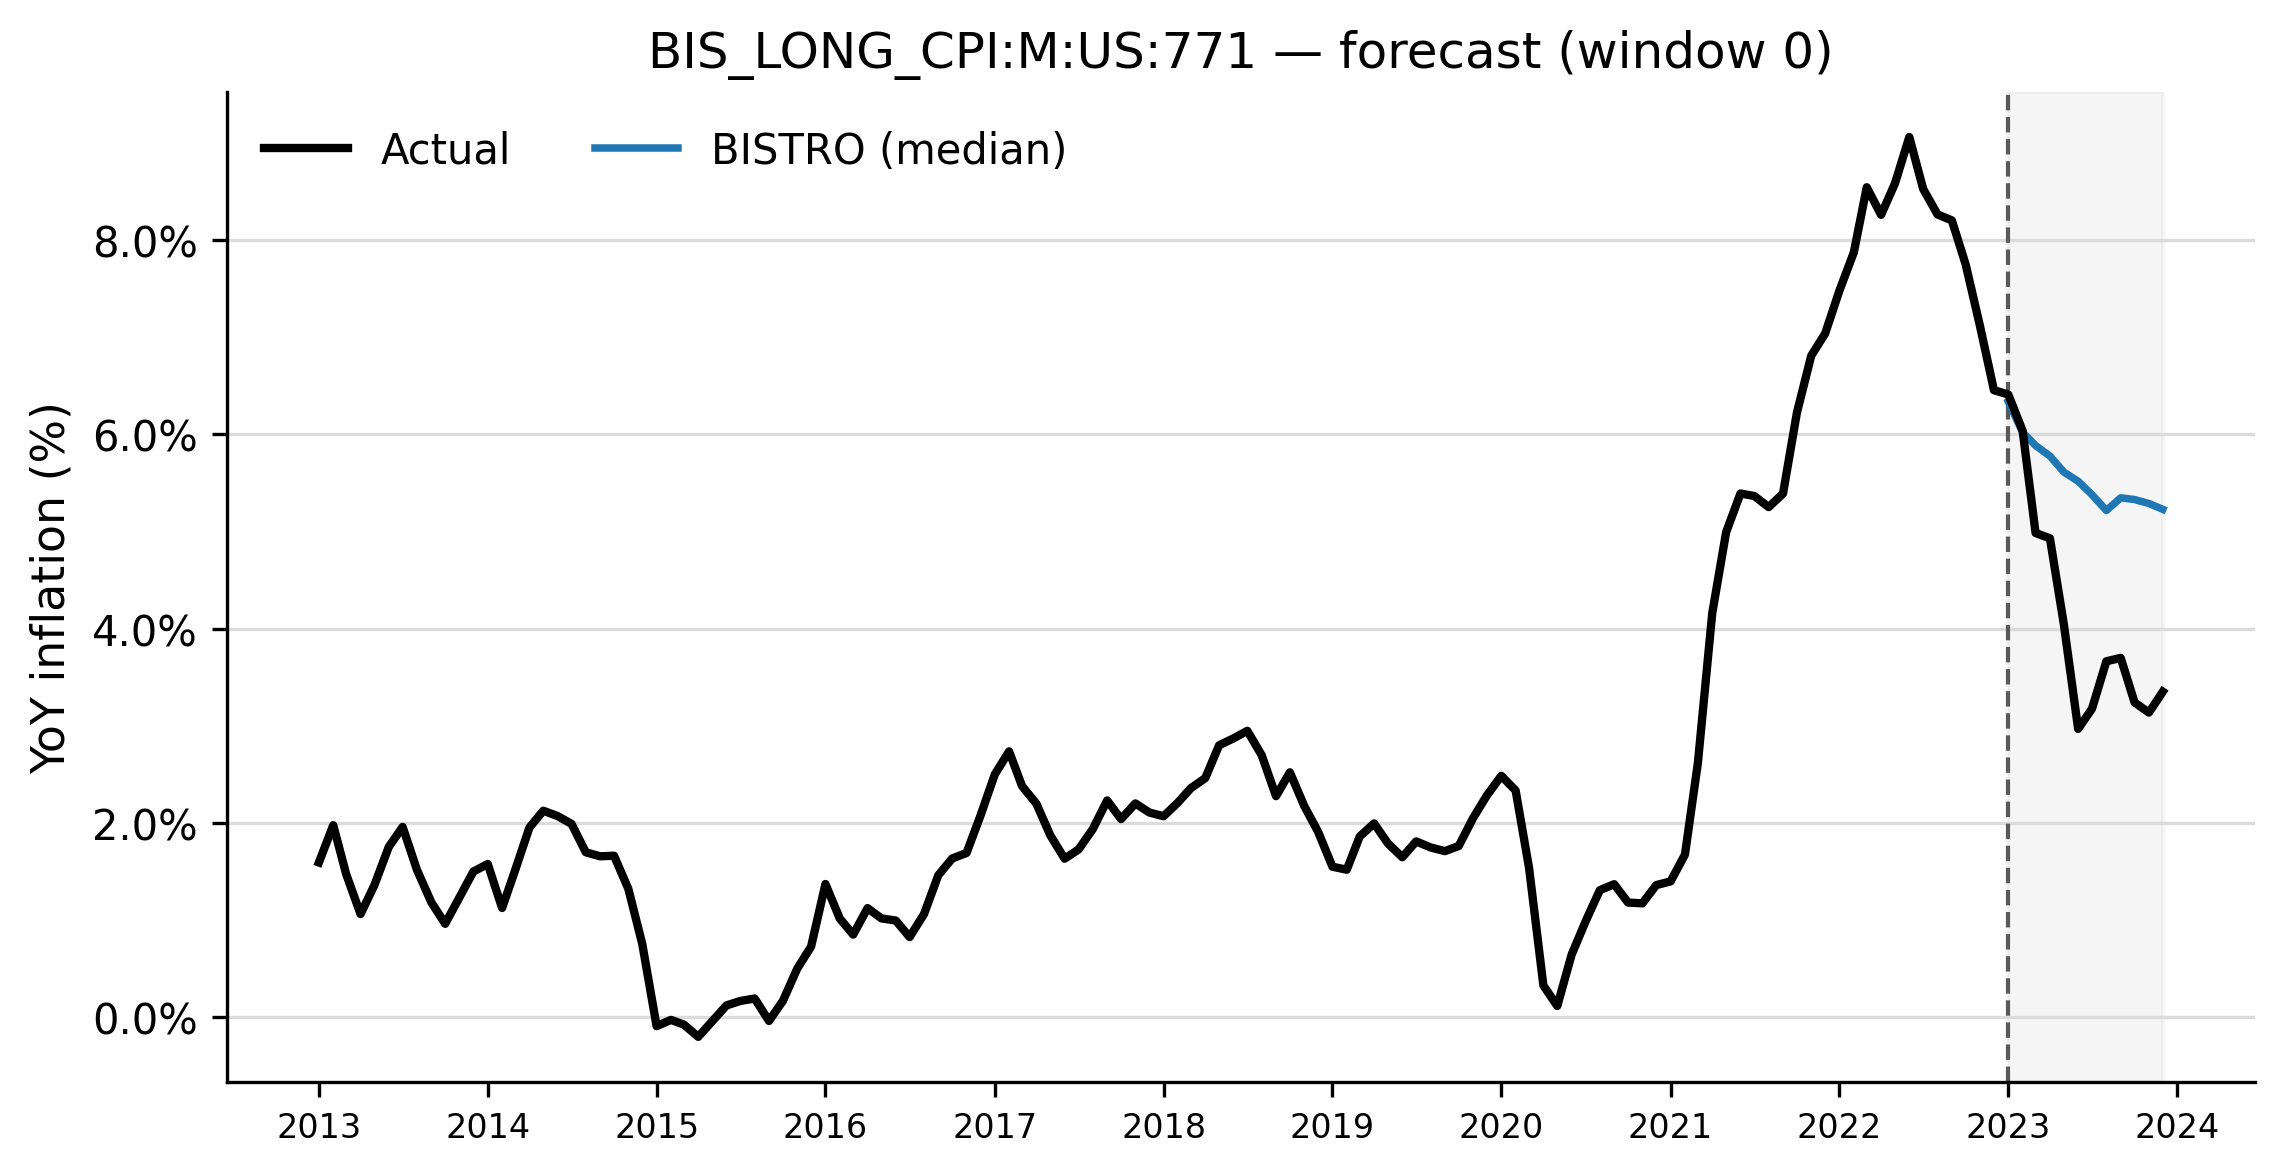

: 

In [ ]:
w = 0

df_actual = prep.df_monthly[[target_col]].rename(columns={target_col: "actual"})
df_pred = bistro_monthly_by_window[w]

plot_from = prep.forecast_start - min(CTX, 120)
plot_to = df_pred.index.max()

df_plot = df_actual.join(df_pred[["bistro_pred"]], how="outer").sort_index()
df_plot = df_plot.loc[plot_from:plot_to]

fig, ax = plot_publication_forecast_comparison(
    df_plot,
    actual_col="actual",
    forecast_cols={"bistro_pred": "BISTRO (median)"},
    forecast_start=prep.forecast_start,
    title=f"{target_col} — forecast (window {w})",
    ylabel="YoY inflation (%)",
    y_fmt="percent",
    percent_scale=100.0,
    savepaths=[
        repo_root / "script" / "figures" / "forecast_single_timeseries.png",
    ],
)

fig